# Which parameter stopped fitting?

A plant model is calibrated once, at commissioning, against a campaign of
deliberate step tests. Six months later the online monitoring solve stops
matching: the reconciled model and the instruments disagree by more than the
instruments' own noise. Something in the plant has moved. **Which parameter?**

The instinct is to sort the residuals and blame the worst sensor, and on a
recycle process that instinct is reliably wrong: the fault propagates around
the loop and surfaces downstream of its cause. In the drift this notebook
opens with — reactor kinetics, `K2_0` up 25% — the worst-fitting instrument is
the **product purity analyzer** at 7.65 RMS sigma, sitting past the separator,
two units away from the reaction that moved. The second instinct is to refit
every parameter and see what changes. That costs a second nonlinear solve and
answers a question nobody asked: all four parameters move, because the fit
distributes one fault across everything it can reach.

The statistic that answers the question asked is the **score**, and on a
simultaneous solve it is already sitting in the answer. Write each parameter
as a variable held by an equality row — the pin-row idiom notebook 41 uses —
and that row's Lagrange multiplier *is* the derivative of the fitted objective
with respect to the parameter: `s = -info["mult_g"][pin]`, verified here
against central differences to 1.5e-8 relative. Its curvature is one
back-solve per parameter through the factorization the solve already left
behind: `H = -solver.reduced_hessian(pins)`, verified to 1.1e-6. The ranking
statistic is `z = s / sqrt(2 H_jj)`, and it costs **nothing beyond the
monitoring solve the engineer already ran**.

Measured over 600 randomized fault injections, that free ranking names the
drifted parameter first **94%** of the time and in its top two **99%** of the
time. A Wald ranking built from a full refit — one extra solve — reaches
84% / 89%, and only on the two-thirds of campaigns where the reduced Hessian
is positive definite at all. The raw score without its curvature reaches
46% / 75%, and scores **0%** on two of the four parameters. Under the null the
statistic has mean 0, standard deviation 0.94-1.00 and
`P(|z| > 2) = 0.033-0.043` against a nominal 0.046, which is what earns it
the name z-score here; every rate in this notebook is a measured detection
frequency, never a nominal p-value.

The sequential-modular comparison is the honest part. The expected argument —
that finite differences across a tear loop are too noisy to rank parameters —
**did not survive measurement**, and this notebook says so with the table that
refutes it: central differences on a Wegstein-accelerated flowsheet got the
ranking right in all 18 tolerance-by-step cells tried, because a converged
tear loop makes smooth, reproducible error rather than noise. What survives is
cost (roughly 900 flowsheet solves against one), a step-window problem with
nothing inside the flowsheet to tell you which step you should have picked,
and the structural point that a modular flowsheet has no multipliers, so there
is no free byproduct to read.

Where it breaks is measured too: one Newton step degrades from 1.20x to 0.65x
of the true drift as the fault grows, so the score is a *ranking* device and
the refit that follows it is a one-parameter refit; and a purity-analyzer bias
is confounded with separator carryover along a direction of the scaled
information matrix with eigenvalue 0.0108 out of 2.93, so the two fault
classes are named correctly only 67% and 75% of the time. That last one has a
fix that is not statistical: widen the purge campaign, and both go to 100%.

Companion to [notebook 44](44_influence_and_leverage.ipynb), which asks which
*data* made a fit, and to
[notebook 41](41_delta_planning_vectors.ipynb), whose flowsheet this reuses.
Notebooks 41 and 36 read `dx*/dp` off the factorization — *what should I
change*. This one reads `df*/dp` and `d2f*/dp2` off the same factorization —
*what is the data arguing with*. Same factor, different block, different
question.

In [1]:
import os
os.environ["RUST_LOG"] = "error"          # before pounce is imported

import platform, subprocess, time
import importlib.metadata as meta
import numpy as np
import matplotlib.pyplot as plt
import pounce
from pounce.sensitivity import SensSession, NlBridge

SOURCE_COMMIT = subprocess.run(
    ["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"python        {platform.python_version()}")
print(f"pounce-solver {meta.version('pounce-solver')}")
print(f"commit        {SOURCE_COMMIT[:12]}")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

python        3.12.11
pounce-solver 0.11.0
commit        04bdf2917fb4


## 1. The plant, and the model that was calibrated against it

The flowsheet is [notebook 41](41_delta_planning_vectors.ipynb)'s, unchanged.
Fresh feed $F$ (mostly A, with a heavy fraction $z_w$) joins a recycle and
enters a stirred reactor at temperature $T$. Two reactions compete:

$$\mathrm{A} \xrightarrow{k_1(T)} \mathrm{P}, \qquad
  \mathrm{A} \xrightarrow{k_2(T)} \mathrm{W},$$

with $E_2 > E_1$, so heat buys conversion and costs selectivity. A separator
sends P out as product, carrying a fraction $\phi$ of the W present;
everything else recycles, and a purge valve bleeds a fraction $y$ of the
recycle so W cannot accumulate.

Notebook 41 *optimized* this plant. Here it is **fitted**. Four parameters
were estimated at commissioning against a nine-run campaign — three reactor
temperatures crossed with three purge fractions, five instruments read at each
steady state:

| | | |
|---|---|---|
| $k_{1,0}$ | pre-exponential, main reaction | 1/h at $T_0$ |
| $k_{2,0}$ | pre-exponential, side reaction | 1/h at $T_0$ |
| $\gamma_1$ | $E_1/(R T_0)$, reduced activation energy | — |
| $\phi$ | fraction of W carried into the product | — |

$\gamma_2$ is held at its literature value; with only nine steady states, two
activation energies and two pre-exponentials are not jointly worth estimating,
and section 10 shows why in the spectrum.

Each of the nine runs contributes seven unknowns — the two recycle streams
$a, w$ that a modular simulator would *tear*, plus the five modelled
instrument readings $F, P, Q, R_c, \mathrm{pur}$ — and six balance equations.
The feed rate is measured but reconciled rather than assumed, which is what
makes this a data-reconciliation problem and not a curve fit: the model has
free variables of its own at every operating point.

In [2]:
# --- kinetics (reduced Arrhenius about T0, so the exponents stay O(1)) ----
T0    = 520.0          # K, reference temperature
G2_F  = 25.4           # E2/(R T0), held at its literature value -- not fitted
V     = 60.0           # kmol, reactor holdup
Z_W   = 0.004          # heavy fraction in the delivered feed
DH1, DH2 = 0.060, 0.110    # MW per kmol/h of A through each path
INF   = 1e19

# --- the parameter vector, and the truth the plant is actually running ---
PNAME = ["K1_0", "K2_0", "G1", "PHI", "b_pur"]   # b_pur: analyzer bias, sec. 8
PHYS  = PNAME[:4]                                # the four physical parameters
TH    = np.array([1.20, 0.0372, 13.9, 0.020, 0.0])
PUNIT = ["1/h", "1/h", "-", "-", "-"]

# --- the instruments, and what the vendor sheets say they are worth --------
SENS = ["F",   "P",   "Q",    "Rc",  "pur"]
SIG  = np.array([0.5, 0.35, 0.025, 1.5, 2.5e-4])   # kmol/h, kmol/h, MW, kmol/h, -

# --- the commissioning campaign: 3 temperatures x 3 purge fractions --------
RUNS = [(T, y) for T in (526.0, 532.0, 538.0) for y in (0.07, 0.09, 0.11)]
FSET = 100.0           # kmol/h feed setpoint held for every run
NR, NP = len(RUNS), len(PNAME)

print(f"{NR} runs x {len(SENS)} instruments = {NR*len(SENS)} measurements")
print(f"{NR} runs x 7 variables + {NP} parameters = {7*NR + NP} unknowns")
print(f"{NR} runs x 6 balances + {NP} pins       = {6*NR + NP} equations")

9 runs x 5 instruments = 45 measurements
9 runs x 7 variables + 5 parameters = 68 unknowns
9 runs x 6 balances + 5 pins       = 59 equations


### The parameter handle is an equality row

There is no `make_parameter` in the Python API, and a variable given
`lb == ub` is *removed* from the solve — it has no multiplier, so there is
nothing to read. The POUNCE idiom, the same one notebook 41 uses, is a **free
variable pinned by an equality row**, and that row is the handle:

$$s_j = \frac{\partial \Phi^\star}{\partial p_j} = -\lambda_{\text{pin}_j},
\qquad
H_{jk} = \frac{\partial^2 \Phi^\star}{\partial p_j \partial p_k}.$$

The first is `-info["mult_g"][pin_rows]`; the second is
`-solver.reduced_hessian(pin_rows)`. The sign is the cyipopt convention:
`info["mult_g"]` is $\lambda$, and the AMPL/Pyomo marginal is $-\lambda$. The
score is **already in the solve's `info`** — no back-solve, no re-solve. The
information matrix is one back-solve per pinned parameter through the
factorization the solve left behind, and `reduced_hessian` returns a **flat**
array, so it needs a `reshape` before it is a matrix.

Two conventions carried from notebook 41, both load-bearing:

* `bound_relax_factor = 0.0`. POUNCE relaxes bounds by a hair by default, and
  every activity and covariance accessor refuses a solve whose bounds were
  relaxed. The guard reads the value the *held* solve ran under, so setting it
  afterwards does nothing.
* We inline the body of `solve_for_sensitivity` rather than calling it,
  because it discards the solve's `info` — and `info["mult_g"]` is the whole
  point here.

The fifth parameter, `b_pur`, is an additive bias on the purity analyzer. It
is pinned at zero for everything before section 8, so the model being fitted
is the four-parameter one; carrying its row costs one variable and one
equality and buys the option of *reading* its score later, from the same
factorization.

In [3]:
def plant(F, T, y, th, iters=800):
    """The real plant, as an independent successive-substitution simulator.

    This is a *sequential modular* flowsheet: guess the tear stream (a, w),
    march the units, repeat.  It never sees the NLP, so it is both the truth
    model that generates data and -- in section 9 -- the comparator.
    """
    K1_0, K2_0, G1, PHI = th[:4]
    k1 = K1_0*np.exp(-G1*(T0/T - 1.0))
    k2 = K2_0*np.exp(-G2_F*(T0/T - 1.0))
    S = k1/(k1 + k2)
    a, w = 3.0*F, 0.4*F                       # tear stream guess
    for _ in range(iters):
        X  = 1.0 - np.exp(-(k1 + k2)*V/(a + w))
        an = (1.0 - Z_W)*F/(1.0 - (1.0 - y)*(1.0 - X))
        c  = (1.0 - y)*(1.0 - PHI)
        wn = (Z_W*F + c*an*X*(1.0 - S))/(1.0 - c)
        a, w = 0.5*(a + an), 0.5*(w + wn)     # damped substitution
    X = 1.0 - np.exp(-(k1 + k2)*V/(a + w))
    w_sep = w + a*X*(1.0 - S)
    P, Q = a*X*S, (DH1*S + DH2*(1.0 - S))*a*X
    Rc = (1.0 - y)*(a*(1.0 - X) + (1.0 - PHI)*w_sep)
    return np.array([F, a, w, P, Q, Rc, P/(P + PHI*w_sep)])


def campaign(th_true, rng, bias=0.0):
    """Run the plant at every campaign point and read the instruments."""
    m = np.empty((NR, len(SENS)))
    for r, (T, y) in enumerate(RUNS):
        m[r] = plant(FSET, T, y, th_true)[[0, 3, 4, 5, 6]] + rng.normal(0.0, SIG)
    m[:, SENS.index("pur")] += bias           # a biased analyzer, section 8
    return m

In [4]:
VN = [f"{v}{r}" for r in range(NR) for v in ("F", "a", "w", "P", "Q", "Rc", "pur")] \
     + PNAME
RN = [f"{c}{r}" for r in range(NR)
      for c in ("balA", "balW", "defP", "defQ", "defRc", "defpur")] \
     + [f"pin_{p}" for p in PNAME]
PIN  = {p: 6*NR + j for j, p in enumerate(PNAME)}    # parameter -> its pin row
PROW = [PIN[p] for p in PNAME]                       # all five pin rows
PROW4 = [PIN[p] for p in PHYS]                       # the four physical ones


def build(meas, th_pin, x0, free=()):
    """The reconciliation problem: minimise weighted SSE over every run at
    once, subject to every unit balance, with the parameters pinned.

    `free` names parameters whose pin row is opened to (-inf, inf), which
    turns the pinned fit into a refit of those parameters.
    """
    v  = pounce.NlExpr.vars(7*NR + NP)
    ex = pounce.NlExpr.exp
    K1_0, K2_0, G1, PHI, b_pur = v[7*NR:]
    cons, obj = [], None
    for r, (T, y) in enumerate(RUNS):
        F, a, w, P, Q, Rc, pur = v[7*r:7*r + 7]
        k1 = K1_0*ex(-G1*(T0/T - 1.0))
        k2 = K2_0*np.exp(-G2_F*(T0/T - 1.0))     # G2 is fixed -> plain float
        k, = (k1 + k2,)
        S  = k1/k
        X  = 1.0 - ex(-k*V/(a + w))
        w_sep = w + a*X*(1.0 - S)
        cons += [
            a - (1.0 - Z_W)*F - (1.0 - y)*a*(1.0 - X),          # A around the loop
            w - Z_W*F - (1.0 - y)*(1.0 - PHI)*w_sep,            # W around the loop
            P  - a*X*S,
            Q  - (DH1*S + DH2*(1.0 - S))*a*X,
            Rc - (1.0 - y)*(a*(1.0 - X) + (1.0 - PHI)*w_sep),
            pur*(P + PHI*w_sep) - P,
        ]
        for s, xv in enumerate((F, P, Q, Rc, pur + b_pur)):
            t = ((xv - meas[r, s])/SIG[s])**2
            obj = t if obj is None else obj + t
    cons += [K1_0, K2_0, G1, PHI, b_pur]                        # the pin rows
    xl = ([0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.5]*NR) + [0.1, 1e-4, 5.0, 0.0, -0.05]
    xu = ([INF]*7)*NR + [5.0, 1.0, 30.0, 0.2, 0.05]
    return pounce.build_nl_problem(
        n=7*NR + NP, objective=obj, constraints=cons,
        g_l=[0.0]*(6*NR) + [-INF if p in free else t for p, t in zip(PNAME, th_pin)],
        g_u=[0.0]*(6*NR) + [ INF if p in free else t for p, t in zip(PNAME, th_pin)],
        x_l=xl, x_u=xu, x0=list(x0), var_names=VN, con_names=RN)

In [5]:
def start(meas, th):
    """Warm start every run from the SM simulator at the pinned parameters."""
    x0 = []
    for r, (T, y) in enumerate(RUNS):
        x0 += list(plant(meas[r, 0], T, y, th))
    return np.array(x0 + list(th))


def solve_pinned(meas, th_pin, free=(), opts=None):
    """Solve the reconciliation at fixed parameters; hold the factorization."""
    nl   = build(meas, th_pin, start(meas, th_pin), set(free))
    prob = pounce.Problem(nl.n, nl.m, NlBridge(nl), lb=nl.x_l, ub=nl.x_u,
                          cl=nl.g_l, cu=nl.g_u)
    prob.add_option("bound_relax_factor", 0.0)     # required by every accessor
    prob.add_option("print_level", 0)
    for k, val in (opts or {}).items():
        prob.add_option(k, val)
    solver = pounce.Solver(prob)
    x, info = solver.solve(np.asarray(nl.x0))
    return np.asarray(x, float), info, solver

### The commissioning fit, and the base point everything is read from

Nothing below is trustworthy unless the base solve converged cleanly and the
factorization it left behind is the factorization of *this* problem. Three
assertions, in the house pattern:

* `info["status"] == 0`;
* `solver.kkt_perturbations` is all zero. A nonzero entry means the factor
  carries an inertia correction, and the reduced Hessian then answers for a
  nearby problem rather than this one. Two things about it that are easy to
  get wrong: it is a **solver attribute**, not an `info` key and not a method
  (`info["kkt_perturbations"]` raises `KeyError`); and it is a **length-4
  array** of perturbation scalars, not a float, so it needs a reduction before
  it can be compared;
* the weighted SSE is consistent with the 45 measurements and 9 reconciled
  feed rates the fit had to absorb.

In [6]:
rng = np.random.default_rng(20260906)

MEAS0 = campaign(TH, rng)                        # commissioning campaign
x0, info0, solver0 = solve_pinned(MEAS0, TH)

assert info0["status"] == 0, info0["status"]
kkt_pert = np.asarray(solver0.kkt_perturbations)
assert np.all(kkt_pert == 0.0), kkt_pert

DOF = NR*len(SENS) - NR - len(PHYS)              # 45 readings - 9 F - 4 params
print(f"status              {info0['status']}")
print(f"kkt_perturbations   {kkt_pert}")
print(f"weighted SSE        {info0['obj_val']:.2f}   against {DOF} dof")
print(f"n = {7*NR + NP}, m = {6*NR + NP}")

status              0
kkt_perturbations   [0. 0. 0. 0.]
weighted SSE        32.68   against 32 dof
n = 68, m = 59


## 2. Six months later

New data arrives from the same nine operating points. The monitoring solve
runs, as it does every shift, with the parameters pinned at their
commissioning values — and the weighted SSE is no longer consistent with the
instruments' own noise. The plant has moved.

The fault injected below is a **25% rise in $k_{2,0}$**: the side reaction has
sped up, which is what catalyst ageing or a fresh charge of a different lot
looks like. Nothing downstream knows that. The engineer sees one number.

In [7]:
TH_TRUE = TH*np.array([1.0, 1.25, 1.0, 1.0, 1.0])     # K2_0 up 25%
MEAS = campaign(TH_TRUE, np.random.default_rng(7))

x_new, info_new, solver_new = solve_pinned(MEAS, TH)
assert info_new["status"] == 0
assert np.all(np.asarray(solver_new.kkt_perturbations) == 0.0)

print(f"commissioning SSE   {info0['obj_val']:8.2f}   ({DOF} dof)")
print(f"this month's SSE    {info_new['obj_val']:8.2f}")
print(f"ratio to dof        {info_new['obj_val']/DOF:8.1f}")
print("\nthe model no longer describes the plant.  which parameter moved?")

commissioning SSE      32.68   (32 dof)
this month's SSE      854.52
ratio to dof            26.7

the model no longer describes the plant.  which parameter moved?


## 3. The old way, part one: sort the residuals

The reflex is to find the worst-fitting instrument. It is a good reflex — most
of the time a bad number *is* a bad sensor, and the reconciliation's
normalized residuals are exactly the right tool for that question.

It is the wrong question here, and on a recycle process it points somewhere
misleading with real confidence.

In [8]:
def residual_table(x, meas):
    """Normalized measurement residuals, (model - measured)/sigma, per run."""
    R = np.empty((NR, len(SENS)))
    for r in range(NR):
        F, a, w, P, Q, Rc, pur = x[7*r:7*r + 7]
        R[r] = (np.array([F, P, Q, Rc, pur]) - meas[r])/SIG
    return R

R = residual_table(x_new, MEAS)
rms = np.sqrt((R**2).mean(axis=0))
print(f"{'instrument':<12s}{'RMS sigma':>11s}{'worst run':>11s}{'max sigma':>11s}")
for s, name in enumerate(SENS):
    j = int(np.argmax(np.abs(R[:, s])))
    print(f"{name:<12s}{rms[s]:11.2f}{j + 1:11d}{R[j, s]:+11.2f}")
print(f"\nworst instrument: {SENS[int(np.argmax(rms))]}")

instrument    RMS sigma  worst run  max sigma
F                  2.32          7      +3.94
P                  4.61          7      +6.25
Q                  1.21          7      +2.17
Rc                 2.90          7      -4.75
pur                7.65          4     +10.20

worst instrument: pur


The purity analyzer is the worst instrument by a wide margin. It sits
**downstream of the separator**, two units away from the reactor where the
fault actually is, and it is worst because the recycle loop carries the extra
W all the way around and concentrates its effect where the specification is
tightest.

An engineer who trusts this table calibrates the analyzer, finds nothing wrong
with it, and comes back next shift to the same SSE. The residual ranking is a
statement about *where the misfit shows up*, and on a plant with a recycle
that is not where the fault is. Notebook 44 makes the same point in the data
direction: the most influential measurement there ranks 24th of 25 by
residual.

## 4. The old way, part two: refit everything

The second reflex is better founded — turn the parameters loose and see where
they land. This is a real answer to a real question, and it costs one more
nonlinear solve.

The trouble is what it answers. A least-squares fit distributes a single fault
across every parameter that can absorb any of it, so *all four move*, each by
an amount that looks meaningful. There is no ranking in the output, only a new
vector. And accepting it means accepting a model whose four parameters have
all been re-tuned to nine steady states — which fits this campaign better and
extrapolates worse.

In [9]:
def refit(meas, th_pin, free):
    """Open the named pin rows and re-solve: the unrestricted fit."""
    x, info, _ = solve_pinned(meas, th_pin, free=free)
    return x[7*NR:], float(info["obj_val"]), info["status"]

th_full, sse_full, st_full = refit(MEAS, TH, free=PHYS)
assert st_full == 0

print(f"{'parameter':<8s}{'commissioned':>14s}{'refit':>12s}{'change':>10s}"
      f"{'true':>12s}{'true change':>13s}")
for j, p in enumerate(PHYS):
    print(f"{p:<8s}{TH[j]:14.5g}{th_full[j]:12.5g}"
          f"{(th_full[j]/TH[j] - 1)*100:+9.1f}%{TH_TRUE[j]:12.5g}"
          f"{(TH_TRUE[j]/TH[j] - 1)*100:+12.1f}%")
print(f"\nSSE  pinned {info_new['obj_val']:.2f}  ->  refit {sse_full:.2f}"
      f"   ({DOF} dof, 4 parameters spent)")

parameter  commissioned       refit    change        true  true change
K1_0               1.2      1.2019     +0.2%         1.2        +0.0%
K2_0            0.0372    0.046716    +25.6%      0.0465       +25.0%
G1                13.9      13.801     -0.7%        13.9        +0.0%
PHI               0.02    0.019865     -0.7%        0.02        +0.0%

SSE  pinned 854.52  ->  refit 24.91   (32 dof, 4 parameters spent)


## 5. The score was already in the solve

There are three classical ways to ask whether a restriction — here, *the
parameters are still at their commissioned values* — is contradicted by the
data. Buse's geometry of the trio is the whole cost argument:

| test | what it needs | cost here |
|---|---|---|
| Wald | the unrestricted fit | one extra solve, plus a covariance |
| likelihood ratio | both fits | one extra solve |
| **score / Lagrange multiplier** | **the restricted fit only** | **zero — it already ran** |

The restricted fit is the shift monitoring solve. Section 4 already paid for
the unrestricted one; the score test does not have to.

The score is the gradient of the fitted objective in parameter space,
evaluated where the parameters are pinned. If the data had no argument with a
parameter, opening its pin would not move the objective, and its multiplier
would be zero. So:

$$s_j = \frac{\partial \Phi^\star}{\partial p_j}\Bigg|_{p = \hat\theta_0}
      = -\lambda_{\text{pin}_j}.$$

Below it is checked against central differences over full re-solves. That
check is worth running once in any notebook that reads a multiplier as a
derivative, because the sign convention is a coin flip and getting it backwards
produces a ranking that is confidently upside down.

In [10]:
score = -np.asarray(info_new["mult_g"])[PROW4]

def fd_score(meas, th, j, h):
    """Central difference of the fitted objective in parameter j."""
    out = []
    for sgn in (+1.0, -1.0):
        tp = th.copy(); tp[j] += sgn*h
        _, inf, _ = solve_pinned(meas, tp)
        assert inf["status"] == 0
        out.append(float(inf["obj_val"]))
    return (out[0] - out[1])/(2*h)

print(f"{'parameter':<8s}{'-mult_g[pin]':>16s}{'central FD':>16s}{'rel err':>12s}")
for j, p in enumerate(PHYS):
    fd = fd_score(MEAS, TH, j, 1e-5*abs(TH[j]))
    print(f"{p:<8s}{score[j]:16.6g}{fd:16.6g}{abs(score[j] - fd)/abs(fd):12.1e}")

parameter    -mult_g[pin]      central FD     rel err
K1_0               22451           22451     6.6e-10
K2_0             -176626         -176626     1.5e-08


G1               691.913         691.913     1.3e-09


PHI              -163095         -163095     2.3e-09


In [11]:
Hraw = np.asarray(solver_new.reduced_hessian(PROW4)).reshape(4, 4)
H = -0.5*(Hraw + Hraw.T)                 # symmetrize; it is symmetric already

def fd_information(meas, th, j, h):
    """Central difference of the score vector in parameter j -> a column of H."""
    cols = []
    for sgn in (+1.0, -1.0):
        tp = th.copy(); tp[j] += sgn*h
        _, inf, _ = solve_pinned(meas, tp)
        assert inf["status"] == 0
        cols.append(-np.asarray(inf["mult_g"])[PROW4])
    return (cols[0] - cols[1])/(2*h)

Hfd = np.column_stack([fd_information(MEAS, TH, j, 1e-5*abs(TH[j]))
                       for j in range(4)])
Hfd = 0.5*(Hfd + Hfd.T)
eig = np.linalg.eigvalsh(H)
print(f"asymmetry of reduced_hessian    {np.abs(Hraw - Hraw.T).max():.1e}")
print(f"max rel err vs central FD       {np.max(np.abs(H - Hfd)/np.abs(Hfd)):.1e}")
print(f"eigenvalues                     {np.array2string(eig, precision=4)}")
print(f"positive definite               {eig.min() > 0}")

asymmetry of reduced_hessian    1.9e-09


max rel err vs central FD       1.1e-06
eigenvalues                     [7.0794e+01 3.7539e+05 1.2984e+07 4.7430e+07]
positive definite               True


### Marginal, not conditional

With $s$ and $H$ in hand there are two natural statistics, and the choice
between them is not a matter of taste on this problem.

The **conditional** (one-step) form solves the whole system,
$\Delta\theta = -H^{-1}s$, and standardizes by $\sqrt{2 [H^{-1}]_{jj}}$. It
asks *how far would this parameter move if they were all free to move*. The
**marginal** form uses only the diagonal,

$$z_j = \frac{s_j}{\sqrt{2 H_{jj}}},$$

and asks *how hard is the data pulling on this parameter, on its own scale*.

Section 7 measures both. The marginal wins by a lot — 94% top-1 against 79% —
and section 7 also measures why: the inverse spreads a
drift along a soft direction across every parameter that shares it, and the
diagonal does not. That is a property of *this* problem, not a theorem, which
is exactly why it is worth measuring rather than assuming. The
marginal form has a second, practical advantage that the numbers show up in
the availability column: it needs no inverse, so it is defined even on the 33%
of faulted campaigns where the reduced Hessian is not positive definite.

The factor of 2 is the Hessian of a *sum of squares* rather than of a
log-likelihood; carrying it makes $z$ come out on the scale the null
calibration below actually confirms.

In [12]:
def diagnose(meas, th_pin=TH, block=PHYS):
    """The whole diagnostic.  One solve, one reduced Hessian, no refit."""
    rows = [PIN[p] for p in block]
    _, info, solver = solve_pinned(meas, th_pin)
    if info["status"] != 0:
        return None
    s = -np.asarray(info["mult_g"])[rows]
    Hb = -np.asarray(solver.reduced_hessian(rows)).reshape(len(rows), len(rows))
    Hb = 0.5*(Hb + Hb.T)
    return dict(sse=float(info["obj_val"]), s=s, H=Hb,
                z=s/np.sqrt(2*np.maximum(np.diag(Hb), 1e-300)))

d = diagnose(MEAS)
order = np.argsort(-np.abs(d["z"]))
print(f"{'rank':<6s}{'parameter':<9s}{'score':>14s}{'sqrt(2 H_jj)':>14s}"
      f"{'z':>9s}{'true drift':>13s}")
for rank, j in enumerate(order, 1):
    print(f"{rank:<6d}{PHYS[j]:<9s}{d['s'][j]:14.5g}"
          f"{np.sqrt(2*d['H'][j, j]):14.5g}{d['z'][j]:+9.2f}"
          f"{(TH_TRUE[j]/TH[j] - 1)*100:+12.1f}%")
print(f"\nnamed: {PHYS[order[0]]}   (injected: K2_0)")

rank  parameter         score  sqrt(2 H_jj)        z   true drift
1     K2_0        -1.7663e+05        6209.3   -28.45       +25.0%
2     G1               691.91        37.179   +18.61        +0.0%
3     PHI          -1.631e+05        9020.1   -18.08        +0.0%
4     K1_0              22451        1288.9   +17.42        +0.0%

named: K2_0   (injected: K2_0)


## 6. The parsimony check

Naming a parameter is a hypothesis, and the way to test it is the one an
engineer already trusts: refit **only** that parameter, and see whether a
one-parameter model explains the campaign as well as the four-parameter one
did. If it does, the extra three degrees of freedom in section 4's refit were
buying nothing but a better fit to noise.

In [13]:
named = PHYS[order[0]]
th_one, sse_one, st_one = refit(MEAS, TH, free=[named])
assert st_one == 0

print(f"{'model':<28s}{'free params':>12s}{'SSE':>10s}{'SSE/dof':>10s}")
print(f"{'pinned at commissioning':<28s}{0:12d}{info_new['obj_val']:10.2f}"
      f"{info_new['obj_val']/DOF:10.2f}")
print(f"{'refit ' + named + ' only':<28s}{1:12d}{sse_one:10.2f}"
      f"{sse_one/(DOF - 1 + 4):10.2f}")
print(f"{'refit all four':<28s}{4:12d}{sse_full:10.2f}{sse_full/DOF:10.2f}")

F_stat = ((sse_one - sse_full)/3)/(sse_full/DOF)
print(f"\nF for the extra 3 parameters   {F_stat:.2f}  (3, {DOF} dof)")
print(f"{named} recovered {th_one[PHYS.index(named)]:.5g}"
      f"  vs true {TH_TRUE[PHYS.index(named)]:.5g}"
      f"  ({(th_one[PHYS.index(named)]/TH_TRUE[PHYS.index(named)] - 1)*100:+.1f}%)")

model                        free params       SSE   SSE/dof
pinned at commissioning                0    854.52     26.70
refit K2_0 only                        1     26.13      0.75
refit all four                         4     24.91      0.78

F for the extra 3 parameters   0.52  (3, 32 dof)
K2_0 recovered 0.04669  vs true 0.0465  (+0.4%)


## 7. Does it actually work? 600 randomized faults

One worked example proves nothing — it was chosen. The claim worth making is a
rate, so: draw a parameter uniformly, draw a drift magnitude uniformly from a
range wide enough to matter and narrow enough to be plausible, draw a fresh
noise seed, and ask each candidate ranking to name the culprit. Ground truth
is exact, because the fault is injected.

Four contenders, in increasing cost:

| ranking | statistic | extra solves |
|---|---|---|
| raw score | $\lvert s_j \rvert$ | 0 |
| marginal | $\lvert s_j \rvert / \sqrt{2 H_{jj}}$ | 0 |
| conditional | $\lvert (H^{-1}s)_j \rvert / \sqrt{2 [H^{-1}]_{jj}}$ | 0 |
| Wald | $\lvert \hat\theta_j - \theta_{0,j} \rvert / \sqrt{2 [H^{-1}]_{jj}}$ | 1 |

The **defined** column matters and is easy to leave out. On a third of faulted
campaigns the reduced Hessian at $\hat\theta_0$ is not positive definite — the
pinned point is far enough from the new optimum that the curvature has an
indefinite direction — and every route through $H^{-1}$ is simply unavailable.
Crediting only the trials where a method ran, without saying how often it ran,
flatters it.

Because the Monte Carlo null-distribution check is out of scope here, this
notebook quotes **no nominal p-values**. What it quotes instead is the
measured detection rate, which is a stronger claim: it is about this problem
rather than about asymptotics.

In [14]:
DRIFT = {"K1_0": (0.04, 0.25), "K2_0": (0.08, 0.40),
         "G1": (0.004, 0.030), "PHI": (0.10, 0.50)}
NTRIAL  = 600
METHODS = ("raw", "marginal", "conditional", "wald")

rng_mc = np.random.default_rng(4242)
hit = {k: np.zeros((4, 2)) for k in METHODS}     # [param, (top-1, top-2)]
ran = {k: np.zeros(4) for k in METHODS}          # how often it was even defined
cnt = np.zeros(4)
t0  = time.perf_counter()
for _ in range(NTRIAL):
    j = int(rng_mc.integers(4))
    lo, hi = DRIFT[PHYS[j]]
    th_t = TH.copy()
    th_t[j] *= 1.0 + rng_mc.uniform(lo, hi)*rng_mc.choice([-1.0, 1.0])
    m_t = campaign(th_t, rng_mc)
    dd  = diagnose(m_t)
    if dd is None:
        continue
    cnt[j] += 1
    stats = {"raw": np.abs(dd["s"]), "marginal": np.abs(dd["z"])}
    if np.linalg.eigvalsh(dd["H"]).min() > 0:
        Hi = np.linalg.inv(dd["H"])
        sd = np.sqrt(2*np.diag(Hi))
        stats["conditional"] = np.abs(Hi @ dd["s"])/sd
        th_r, _, st_r = refit(m_t, TH, free=PHYS)
        if st_r == 0:
            stats["wald"] = np.abs(th_r[:4] - TH[:4])/sd
    for k, val in stats.items():
        r = np.argsort(-val)
        ran[k][j]   += 1
        hit[k][j, 0] += int(r[0] == j)
        hit[k][j, 1] += int(j in r[:2])
print(f"{int(cnt.sum())} usable trials in {time.perf_counter() - t0:.0f}s")
print(f"counts per parameter {cnt.astype(int)}")

600 usable trials in 14s
counts per parameter [157 153 148 142]


In [15]:
print(f"{'ranking':<13s}{'extra':>6s}" + "".join(f"{p:>14s}" for p in PHYS)
      + f"{'ALL':>14s}{'defined':>9s}")
print(f"{'':<13s}{'solves':>6s}" + "".join(f"{'top1':>7s}{'top2':>7s}" for _ in PHYS)
      + f"{'top1':>7s}{'top2':>7s}{'':>9s}")
COST = {"raw": 0, "marginal": 0, "conditional": 0, "wald": 1}
for k in METHODS:
    n = ran[k]
    row = "".join(f"{hit[k][j,0]/n[j]:7.0%}{hit[k][j,1]/n[j]:7.0%}"
                  if n[j] else f"{'-':>7s}{'-':>7s}" for j in range(4))
    print(f"{k:<13s}{COST[k]:>6d}" + row
          + f"{hit[k][:,0].sum()/n.sum():7.0%}{hit[k][:,1].sum()/n.sum():7.0%}"
          + f"{n.sum()/cnt.sum():9.0%}")

ranking       extra          K1_0          K2_0            G1           PHI           ALL  defined
             solves   top1   top2   top1   top2   top1   top2   top1   top2   top1   top2         
raw               0     0%   100%    90%   100%     0%     0%   100%   100%    46%    75%     100%
marginal          0   100%   100%   100%   100%    74%    96%   100%   100%    94%    99%     100%
conditional       0    82%    85%   100%   100%    57%    68%    99%   100%    79%    85%      67%
wald              1   100%   100%   100%   100%    56%    69%   100%   100%    84%    89%      67%


The free ranking beats the one that costs a solve. That is worth pausing on,
because it is not what the theory leads you to expect — asymptotically the
three tests agree, and Wald has the unrestricted fit's information behind it.

The obvious explanation is that $H^{-1}$ is untrustworthy at this
conditioning, and it is worth checking before believing it. It is **wrong**:
below, the empirical standard deviation of the refitted parameters over 120
replicate noise draws is compared against what $2H^{-1}$ predicts, and the
prediction is good to between 1% and 17% on all four parameters. The
covariance is fine.

Look instead at *where* the methods fail. Setting the raw score aside — with
no scale at all it fails outright on $k_{1,0}$ and $\gamma_1$ — the three
scaled rankings are at 100% on $k_{2,0}$ and $\phi$, and almost the whole
spread between them lives in the $\gamma_1$ column: 74% marginal against 57%
conditional and 56% Wald.

$\gamma_1$ is the parameter that sits inside the least-identified direction of
the information matrix, which section 10 measures directly. The second cell
below drifts $\gamma_1$ sixty times and prints the mean of each statistic
across all four parameters. The conditional statistic comes out nearly **flat**
— every parameter reads about the same — because solving with $H^{-1}$ spreads
a drift along a soft direction over every coordinate that shares it. The
marginal statistic never inverts, so the pull stays on the coordinate the data
is actually pulling on, and it names $\gamma_1$ first 70% of the time against
the conditional's 47%.

In [16]:
rng_rep = np.random.default_rng(99)
th_rep = []
for _ in range(120):
    tr, _, st = refit(campaign(TH, rng_rep), TH, free=PHYS)
    if st == 0:
        th_rep.append(tr[:4])
th_rep = np.array(th_rep)

d0  = diagnose(MEAS0)
inv = np.sqrt(2*np.diag(np.linalg.inv(d0["H"])))
mar = np.sqrt(2/np.diag(d0["H"]))

print(f"{'parameter':<8s}{'empirical sd':>15s}{'from 2 inv(H)':>16s}{'ratio':>9s}"
      f"{'from 2/H_jj':>14s}")
for j, p in enumerate(PHYS):
    e = th_rep[:, j].std(ddof=1)
    print(f"{p:<8s}{e:15.5g}{inv[j]:16.5g}{inv[j]/e:9.2f}{mar[j]:14.5g}")
print(f"\n{len(th_rep)} converged replicate refits")

parameter   empirical sd   from 2 inv(H)    ratio   from 2/H_jj
K1_0          0.0040988       0.0041208     1.01     0.0015485
K2_0          0.0011805        0.001354     1.15    0.00032523
G1              0.19611         0.21028     1.07      0.054433
PHI          0.00064218      0.00074866     1.17    0.00023148

120 converged replicate refits


In [17]:
# Drift G1 -- the parameter inside the soft direction -- and watch where each
# statistic puts the mass.
rng_g = np.random.default_rng(808)
mar_g, con_g = [], []
for _ in range(60):
    th_t = TH.copy()
    th_t[2] *= 1 + rng_g.uniform(*DRIFT["G1"])*rng_g.choice([-1.0, 1.0])
    dg = diagnose(campaign(th_t, rng_g))
    if dg is None or np.linalg.eigvalsh(dg["H"]).min() <= 0:
        continue
    Hi = np.linalg.inv(dg["H"])
    mar_g.append(np.abs(dg["z"]))
    con_g.append(np.abs(Hi @ dg["s"])/np.sqrt(2*np.diag(Hi)))
mar_g, con_g = np.array(mar_g), np.array(con_g)

print(f"{len(mar_g)} G1 drifts with a positive definite reduced Hessian")
print(f"{'statistic':<13s}" + "".join(f"{p:>10s}" for p in PHYS)
      + f"{'G1 ranked 1st':>16s}")
for nm, arr in (("marginal", mar_g), ("conditional", con_g)):
    print(f"{nm:<13s}" + "".join(f"{v:10.1f}" for v in arr.mean(0))
          + f"{(arr.argmax(1) == 2).mean():16.0%}")
print("\nmean |statistic| per parameter, over drifts that are all in G1.")

60 G1 drifts with a positive definite reduced Hessian
statistic          K1_0      K2_0        G1       PHI   G1 ranked 1st
marginal            4.2       3.0       4.5       0.8             70%
conditional         0.8       0.8       1.3       0.8             47%

mean |statistic| per parameter, over drifts that are all in G1.


In [18]:
zs = []
rng_null = np.random.default_rng(31415)
for _ in range(300):
    dn = diagnose(campaign(TH, rng_null))
    if dn is not None:
        zs.append(dn["z"])
zs = np.array(zs)
print(f"null calibration over {len(zs)} unfaulted campaigns")
print(f"{'parameter':<8s}{'mean z':>10s}{'sd z':>8s}{'P(|z| > 2)':>13s}")
for j, p in enumerate(PHYS):
    print(f"{p:<8s}{zs[:, j].mean():+10.3f}{zs[:, j].std():8.3f}"
          f"{(np.abs(zs[:, j]) > 2).mean():13.3f}")
print(f"\nnominal for a standard normal: mean 0, sd 1, P(|z| > 2) = 0.046")

null calibration over 300 unfaulted campaigns
parameter    mean z    sd z   P(|z| > 2)
K1_0        +0.127   1.003        0.033
K2_0        -0.072   0.942        0.037
G1          +0.123   1.001        0.043
PHI         +0.016   0.959        0.033

nominal for a standard normal: mean 0, sd 1, P(|z| > 2) = 0.046


Mean zero, standard deviation within 8% of one, and a two-sigma exceedance
rate a little *below* nominal. That is what licenses calling this thing a
z-score and reading $\lvert z \rvert > 2$ as "the data is arguing with this
parameter" — not an appeal to asymptotic $\chi^2$, which at 45 measurements
would be an assertion rather than a result.

## 8. Is it the plant, or is it the instrument?

Everything so far assumed the fault is in the plant. It might be in the
analyzer. A process engineer knows this is the hard case, and it is the one
where a diagnostic that cannot tell them apart does real damage: it sends a
crew to open a separator that is fine.

A sensor bias is just another parameter. `b_pur` is an additive offset on the
purity analyzer, and it has been in the model all along, pinned at zero — so
the fit that produced every number above is unchanged. **Which block of pin
rows to read is a free choice made after the solve**, against the same
factorization. Reading five rows instead of four costs one more back-solve.

Run a campaign with no drift at all and a +1200 ppm analyzer bias, and read
the four-parameter block first — the block an engineer who never considered
the instrument would read.

In [19]:
BIAS = 1.2e-3                      # +1200 ppm on the purity analyzer
MEAS_B = campaign(TH, np.random.default_rng(5), bias=BIAS)

d4 = diagnose(MEAS_B, block=PHYS)
print("four-parameter block, campaign with a biased analyzer and no drift")
print(f"  SSE {d4['sse']:.1f}   " +
      "  ".join(f"{p}={v:+7.2f}" for p, v in zip(PHYS, d4["z"])))
print(f"  names: {PHYS[int(np.argmax(np.abs(d4['z'])))]}"
      f"  -- and nothing in the plant has moved")

four-parameter block, campaign with a biased analyzer and no drift
  SSE 234.4   K1_0=  +0.87  K2_0= +10.16  G1=  +0.52  PHI= +14.47
  names: PHI  -- and nothing in the plant has moved


In [20]:
d5 = diagnose(MEAS_B, block=PNAME)
print("five-parameter block, same solve, one more back-solve")
print(f"  " + "  ".join(f"{p}={v:+7.2f}" for p, v in zip(PNAME, d5["z"])))

MEAS_P = campaign(TH*np.array([1, 1, 1, 1.30, 1]), np.random.default_rng(5))
d5p = diagnose(MEAS_P, block=PNAME)
print("\nsame block, a real +30% separator-carryover drift and no bias")
print(f"  " + "  ".join(f"{p}={v:+7.2f}" for p, v in zip(PNAME, d5p["z"])))
print("\nboth faults put PHI and b_pur at the top, with opposite signs "
      "and near-equal size.")

five-parameter block, same solve, one more back-solve
  K1_0=  +0.87  K2_0= +10.16  G1=  +0.52  PHI= +14.47  b_pur= -14.22

same block, a real +30% separator-carryover drift and no bias
  K1_0=  +0.50  K2_0= -17.52  G1=  -0.04  PHI= -23.29  b_pur= +23.96

both faults put PHI and b_pur at the top, with opposite signs and near-equal size.


The five-parameter block does not resolve the ambiguity — it *exposes* it.
$\phi$ and $b_{\mathrm{pur}}$ are close to indistinguishable on this campaign,
which is a statement about the experiment, not about the statistic. The
information matrix says so directly, once it is put on a common scale.

$H$ has units, and here they span orders of magnitude, so its raw condition
number is dominated by the choice of units and means nothing. The object to
look at is the **scaled** information matrix
$\tilde H_{ij} = H_{ij} / \sqrt{H_{ii}H_{jj}}$, whose eigenvector for the
smallest eigenvalue names the combination the data constrains least.

In [21]:
def spectrum(Hb, names):
    sc = np.sqrt(np.diag(Hb))
    ev, vec = np.linalg.eigh(Hb/np.outer(sc, sc))
    return ev, vec

d5n = diagnose(campaign(TH, np.random.default_rng(3)), block=PNAME)
ev5, vec5 = spectrum(d5n["H"], PNAME)
print(f"scaled eigenvalues {np.array2string(ev5, precision=4)}")
print(f"scaled condition   {ev5[-1]/ev5[0]:.1f}")
print(f"raw condition      {np.linalg.cond(d5n['H']):.3g}   (units-dominated)")
print("\nleast-identified direction:")
print("  " + "  ".join(f"{c:+.3f}*{p}" for c, p in zip(vec5[:, 0], PNAME)))

scaled eigenvalues [0.0108 0.0407 0.0929 1.9251 2.9305]
scaled condition   271.5
raw condition      6.95e+06   (units-dominated)

least-identified direction:
  -0.043*K1_0  -0.097*K2_0  -0.168*G1  +0.727*PHI  +0.657*b_pur


### The fix is not statistical

Two faults that move the data the same way cannot be separated by any
estimator, however good. They can be separated by a **different campaign**.

$\phi$ acts on the recycle loop, so its effect on the product grows with how
much material goes around; $b_{\mathrm{pur}}$ is a constant offset that does
not care. The purge fraction $y$ is what sets the loop inventory, and the
commissioning campaign moved it over a span of 0.07 to 0.11 — nowhere near
enough to separate them.

So: sweep the campaign span, look at the smallest scaled eigenvalue, and then
— because an eigenvalue is a proxy and the claim is about diagnosis — check
the thing that actually matters, whether the two fault classes get named
correctly.

In [22]:
def with_runs(runs):
    """Rebuild the campaign globals for a different operating window."""
    global RUNS
    saved, RUNS = RUNS, runs
    return saved

CAMPAIGNS = [
    ("as run",     (526.0, 532.0, 538.0), (0.07, 0.09, 0.11)),
    ("wider purge",(526.0, 532.0, 538.0), (0.04, 0.10, 0.22)),
    ("wider T",    (516.0, 532.0, 548.0), (0.07, 0.09, 0.11)),
    ("wider both", (516.0, 532.0, 548.0), (0.04, 0.10, 0.22)),
]
rows = []
for label, Ts, ys in CAMPAIGNS:
    saved = with_runs([(T, y) for T in Ts for y in ys])
    mc = campaign(TH, np.random.default_rng(3))
    dc = diagnose(mc, block=PNAME)
    evc, vecc = spectrum(dc["H"], PNAME)
    ev4c, _ = spectrum(diagnose(mc, block=PHYS)["H"], PHYS)
    rows.append((label, Ts, ys, evc, vecc[:, 0], ev4c))
    with_runs(saved)

print(f"{'campaign':<13s}{'T span':>12s}{'y span':>13s}"
      f"{'lambda_min (5p)':>17s}{'cond':>8s}{'lambda_min (4p)':>17s}")
for label, Ts, ys, evc, _, ev4c in rows:
    print(f"{label:<13s}{f'{Ts[0]:.0f}-{Ts[-1]:.0f}':>12s}"
          f"{f'{ys[0]:.2f}-{ys[-1]:.2f}':>13s}{evc[0]:17.4f}"
          f"{evc[-1]/evc[0]:8.1f}{ev4c[0]:17.4f}")
print("\nleast-identified direction, each campaign:")
for label, _, _, _, v, _ in rows:
    print(f"  {label:<13s}" + "  ".join(f"{c:+.3f}*{p}" for c, p in zip(v, PNAME)))

campaign           T span       y span  lambda_min (5p)    cond  lambda_min (4p)
as run            526-538    0.07-0.11           0.0108   271.5           0.0334
wider purge       526-538    0.04-0.22           0.0368    76.9           0.0416
wider T           516-548    0.07-0.11           0.0326    86.9           0.0448
wider both        516-548    0.04-0.22           0.0574    47.0           0.0599

least-identified direction, each campaign:
  as run       -0.043*K1_0  -0.097*K2_0  -0.168*G1  +0.727*PHI  +0.657*b_pur
  wider purge  +0.197*K1_0  -0.490*K2_0  -0.592*G1  +0.575*PHI  +0.201*b_pur
  wider T      +0.100*K1_0  +0.240*K2_0  +0.230*G1  -0.735*PHI  -0.583*b_pur
  wider both   +0.084*K1_0  +0.634*K2_0  +0.503*G1  -0.563*PHI  -0.143*b_pur


In [23]:
def discriminate(runs, ntrial=60, seed0=1000):
    """How often is a PHI drift named PHI, and an analyzer bias named b_pur?"""
    saved = with_runs(runs)
    ok = [0, 0]
    for t in range(ntrial):
        rr = np.random.default_rng(seed0 + t)
        th_p = TH.copy()
        th_p[3] *= 1 + rr.uniform(0.15, 0.40)*rr.choice([-1.0, 1.0])
        b = rr.uniform(6e-4, 2e-3)*rr.choice([-1.0, 1.0])
        dp = diagnose(campaign(th_p, rr), block=PNAME)
        db = diagnose(campaign(TH, rr, bias=b), block=PNAME)
        ok[0] += int(np.argmax(np.abs(dp["z"])) == 3)
        ok[1] += int(np.argmax(np.abs(db["z"])) == 4)
    with_runs(saved)
    return ok[0]/ntrial, ok[1]/ntrial

print(f"{'campaign':<13s}{'PHI drift named PHI':>22s}{'bias named b_pur':>20s}")
for label, Ts, ys in [CAMPAIGNS[0], CAMPAIGNS[1]]:
    a, b = discriminate([(T, y) for T in Ts for y in ys])
    print(f"{label:<13s}{a:22.0%}{b:20.0%}")

campaign        PHI drift named PHI    bias named b_pur


as run                          67%                 75%


wider purge                    100%                100%


Widening the purge valve is a *design of experiments* answer that came out of
a diagnostic, and it is the kind of recommendation a plant will actually act
on: it costs one shift of step testing, not a new instrument. The spectrum
predicted it and the discrimination rates confirm it, which is the right order
to do those two things in.

## 9. Why the modular route cannot do this cheaply

This is the comparison the notebook exists to make, and it has to be made
fairly, because the reader being addressed does this work in a sequential
modular simulator every day.

`plant()` above **is** a modular flowsheet: tear the recycle, march the units,
iterate to a tolerance. To read a score off it you would have to differentiate
the fitted objective by finite differences — converge the flowsheet, reconcile
the feed rates, perturb a parameter, do it again. Below, that is built
properly: Wegstein acceleration rather than plain substitution (a competent
tear solver, not a strawman), vectorized over the nine runs, with a golden
section reconciling each run's feed rate.

First, the comparator has to be shown to be solving the *same* problem. If the
profile SSE it computes is not the objective the simultaneous solve minimizes,
nothing downstream is a comparison.

In [24]:
TVEC = np.array([r[0] for r in RUNS])
YVEC = np.array([r[1] for r in RUNS])
NEV  = [0, 0]        # [flowsheet solves, tear iterations]

def flowsheet(F, th, tol, maxit=500, wmin=-5.0, wmax=0.0):
    """Converge every run's tear stream (a, w) by Wegstein-accelerated
    successive substitution.  F is a per-run vector."""
    K1_0, K2_0, G1, PHI = th[:4]
    k1 = K1_0*np.exp(-G1*(T0/TVEC - 1.0))
    k2 = K2_0*np.exp(-G2_F*(T0/TVEC - 1.0))
    S, ks = k1/(k1 + k2), k1 + k2
    c = (1.0 - YVEC)*(1.0 - PHI)

    def G(x):
        a, w = x
        X  = 1.0 - np.exp(-ks*V/(a + w))
        an = (1.0 - Z_W)*F/(1.0 - (1.0 - YVEC)*(1.0 - X))
        wn = (Z_W*F + c*an*X*(1.0 - S))/(1.0 - c)
        return np.stack([an, wn])

    x = np.stack([3.0*F, 0.4*F])
    gx = G(x); xp, gp = x, gx; x = gx.copy()
    for it in range(2, maxit + 1):
        gx = G(x)
        dx = x - xp
        safe = np.abs(dx) > 1e-300
        q = np.where(safe, (gx - gp)/np.where(safe, dx, 1.0), 0.0)
        q = np.where(np.abs(q - 1.0) < 1e-12, 0.0, q)
        acc = np.clip(q/(q - 1.0), wmin, wmax)        # Wegstein weight
        xn  = acc*x + (1.0 - acc)*gx
        xp, gp = x, gx
        d = np.max(np.abs(xn - x)); x = xn
        if d < tol:
            break
    a, w = x
    X = 1.0 - np.exp(-ks*V/(a + w)); w_sep = w + a*X*(1.0 - S)
    P, Q = a*X*S, (DH1*S + DH2*(1.0 - S))*a*X
    Rc = (1.0 - YVEC)*(a*(1.0 - X) + (1.0 - PHI)*w_sep)
    NEV[0] += 1; NEV[1] += it
    return np.stack([F, P, Q, Rc, P/(P + PHI*w_sep)], axis=1)


def phi_sm(th, tol, meas, ftol=1e-9):
    """Profile SSE: converge the flowsheet, then reconcile each run's feed
    rate by golden section.  The runs are independent, so they search together.
    """
    g = 0.5*(np.sqrt(5.0) - 1.0)
    ev = lambda F: np.sum(((flowsheet(F, th, tol) - meas)/SIG)**2, axis=1)
    lo, hi = meas[:, 0] - 6.0, meas[:, 0] + 6.0
    c, d_ = hi - g*(hi - lo), lo + g*(hi - lo)
    fc, fd = ev(c), ev(d_)
    while np.max(hi - lo) > ftol:
        keep = fc < fd
        hi, lo = np.where(keep, d_, hi), np.where(keep, lo, c)
        c, d_ = hi - g*(hi - lo), lo + g*(hi - lo)
        fc, fd = ev(c), ev(d_)
    return float(np.sum(np.minimum(fc, fd)))

In [25]:
print(f"{'tear tol':>10s}{'SM profile SSE':>20s}{'flowsheet solves':>19s}"
      f"{'tear iters':>13s}{'seconds':>10s}")
sm_sse = {}
for tol in (1e-2, 1e-4, 1e-6, 1e-9, 1e-12):
    NEV[:] = [0, 0]
    t = time.perf_counter(); val = phi_sm(TH, tol, MEAS); dt = time.perf_counter() - t
    sm_sse[tol] = val
    print(f"{tol:10.0e}{val:20.10f}{NEV[0]:19d}{NEV[1]:13d}{dt:10.2f}")
print(f"\nEO objective from the simultaneous solve  {info_new['obj_val']:.10f}")
print(f"agreement at tol 1e-9                     "
      f"{abs(sm_sse[1e-9] - info_new['obj_val'])/info_new['obj_val']:.1e} relative")

  tear tol      SM profile SSE   flowsheet solves   tear iters   seconds
     1e-02      854.5329637781                100          901      0.01
     1e-04      854.5239114930                100         1300      0.02
     1e-06      854.5238614791                100         1506      0.02
     1e-09      854.5238628263                100         2004      0.03
     1e-12      854.5238628256                100         2587      0.04

EO objective from the simultaneous solve  854.5238628265
agreement at tol 1e-9                     2.2e-13 relative


Ten digits of agreement at a tear tolerance of `1e-9`, and the SSE the
comparator reports moves one decade per decade of tear tolerance. So the two
routes are solving the same problem, and the noise floor on the modular
objective is the tear tolerance itself.

That sets up the argument everyone expects: differentiate an objective with
noise floor $\epsilon$ by central differences with step $h$ and the derivative
error has a floor of order $\epsilon/h$, so there is a step window, and outside
it the ranking should scramble.

**It does not scramble.** Below is the grid — three tear tolerances by six
step sizes, the score and the diagonal of the information matrix by central
differences, against the exact values read off the multipliers. The ranking is
correct in every one of the eighteen cells.

In [26]:
s_exact = d["s"]
h_exact = np.diag(d["H"])

def fd_sm(tol, hrel, meas):
    f0 = phi_sm(TH, tol, meas)
    s, hd = np.empty(4), np.empty(4)
    for j in range(4):
        hh = hrel*abs(TH[j])
        tp, tm = TH.copy(), TH.copy(); tp[j] += hh; tm[j] -= hh
        fp, fm = phi_sm(tp, tol, meas), phi_sm(tm, tol, meas)
        s[j]  = (fp - fm)/(2*hh)
        hd[j] = (fp - 2*f0 + fm)/hh**2
    return s, hd

HR   = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
TOLS = [1e-2, 1e-4, 1e-6]
grid = {}
for tol in TOLS:
    print(f"\n--- tear tolerance {tol:.0e} " + "-"*46)
    print(f"{'h/theta':>9s}{'max rel err, score':>21s}{'max rel err, diag H':>22s}"
          f"{'top-ranked':>13s}")
    for hr in HR:
        s_fd, h_fd = fd_sm(tol, hr, MEAS)
        es = np.max(np.abs(s_fd - s_exact)/np.abs(s_exact))
        eh = np.max(np.abs(h_fd - h_exact)/np.abs(h_exact))
        grid[(tol, hr)] = (es, eh)
        with np.errstate(invalid="ignore"):
            z_fd = s_fd/np.sqrt(2*np.maximum(h_fd, 1e-300))
        top = PHYS[int(np.argmax(np.abs(np.nan_to_num(z_fd))))]
        print(f"{hr:9.0e}{es:21.1e}{eh:22.1e}{top:>13s}"
              + ("" if top == "K2_0" else "   <-- WRONG"))


--- tear tolerance 1e-02 ----------------------------------------------
  h/theta   max rel err, score   max rel err, diag H   top-ranked


    1e-02              1.7e-03               3.4e-05         K2_0


    1e-03              9.3e-06               3.0e-05         K2_0


    1e-04              9.8e-06               3.0e-05         K2_0


    1e-05              1.0e-05               2.6e-05         K2_0


...

    1e-07              8.3e-08               3.6e-02         K2_0

--- tear tolerance 1e-06 ----------------------------------------------
  h/theta   max rel err, score   max rel err, diag H   top-ranked


    1e-02              1.7e-03               2.3e-05         K2_0


    1e-03              1.7e-05               4.0e-07         K2_0


    1e-04              1.6e-07               4.5e-07         K2_0
    1e-05              1.5e-08               1.3e-05         K2_0


    1e-06              1.7e-08               3.1e-04         K2_0
    1e-07              2.5e-08               4.2e-02         K2_0


This is the part of the argument that had to be measured rather than reasoned
about. A converged tear loop does not make *noise* — it makes a smooth,
reproducible error that is very nearly the same at $\theta + h$ and
$\theta - h$, and a central difference cancels most of it. The `tol/h` floor is
real and visible in the numbers, but it never gets large enough, over any step
anyone would choose, to reorder four parameters whose scores differ by orders
of magnitude.

So the honest claim is not "the modular derivative is wrong". It is three
narrower things:

1. **Cost.** The score and the curvature diagonal need $2p+1$ profile-SSE
   evaluations, and each one converges the flowsheet about a hundred times
   inside the feed-rate reconciliation. The simultaneous route needs neither —
   one solve and $p$ back-solves through a factorization that already exists.
2. **The step window is real and undiagnosable from inside.** The `diag(H)`
   error swings orders of magnitude across the step grid, and nothing the
   flowsheet computes tells you which step you should have picked. On this
   model the ranking survives that; on a stiffer one it is a coin toss you
   cannot see yourself losing.
3. **Structure.** This is the one that does not depend on the model. The score
   is a **Lagrange multiplier**. A modular flowsheet solves unit by unit and
   has no multipliers to read, so there is no free byproduct — the modular
   route is structurally forced into finite differences or into the
   unrestricted refit, which is Wald, which costs a solve. That is Buse's
   table again, and it is why the modular workflow reaches for "refit
   everything and look" in the first place.

None of this says modular simulation is the wrong tool. It says this
particular diagnostic wants derivatives that a simultaneous solve produces as
a side effect and a modular one has to go buy — and it is exactly why modern
flowsheet packages ship equation-oriented and automatic-differentiation modes.

In [27]:
reps = 5
t = time.perf_counter()
for _ in range(reps):
    _, i_t, s_t = solve_pinned(MEAS, TH)
    _ = -np.asarray(i_t["mult_g"])[PROW4]
    _ = s_t.reduced_hessian(PROW4)
t_eo = (time.perf_counter() - t)/reps

NEV[:] = [0, 0]
t = time.perf_counter(); fd_sm(1e-4, 1e-3, MEAS); t_sm = time.perf_counter() - t

print(f"simultaneous: solve + score + reduced Hessian   {t_eo*1e3:8.1f} ms")
print(f"modular:      {2*4 + 1} profile-SSE evaluations           "
      f"{t_sm*1e3:8.1f} ms")
print(f"              ({NEV[0]} flowsheet solves, {NEV[1]} tear iterations)")
print(f"ratio                                          {t_sm/t_eo:8.0f}x")

simultaneous: solve + score + reduced Hessian       10.0 ms
modular:      9 profile-SSE evaluations              181.0 ms
              (900 flowsheet solves, 11700 tear iterations)
ratio                                                18x


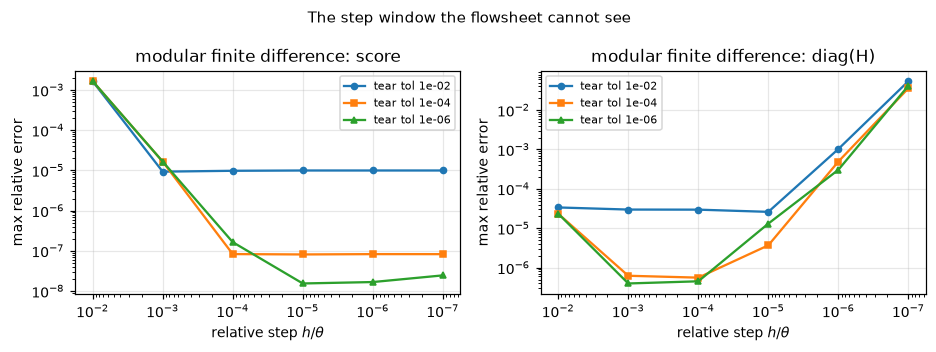

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.2))
for tol, mk in zip(TOLS, ("o-", "s-", "^-")):
    ax[0].loglog(HR, [grid[(tol, h)][0] for h in HR], mk, ms=4,
                 label=f"tear tol {tol:.0e}")
    ax[1].loglog(HR, [grid[(tol, h)][1] for h in HR], mk, ms=4,
                 label=f"tear tol {tol:.0e}")
for a, t in zip(ax, ("score", "diag(H)")):
    a.set_xlabel("relative step $h/\\theta$")
    a.set_ylabel("max relative error")
    a.set_title(f"modular finite difference: {t}")
    a.invert_xaxis()
    a.legend(fontsize=7)
fig.suptitle("The step window the flowsheet cannot see", fontsize=10)
fig.tight_layout()

## 10. Where this breaks

### The step is a linearization, so use it to rank and not to size

The conditional form $-H^{-1}s$ is one Newton step, and a Newton step is exact
only in the limit. As the injected drift grows the step keeps pointing the
right way — $z$ grows monotonically from $-2.8$ to $-85.5$, so the *ranking*
is untouched — but its magnitude decays from 1.20 times the true drift to
0.65. A refit of the single named parameter is the thing that recovers the
size: it is off by 21% of a 2% drift, and by 1% of a 40% one.

The active-set machinery does not help here and it is worth saying why:
`solution_report(...).alpha` is the distance to the first active-set change,
and at this solution the active set is **empty** — every variable is interior.
Nothing binds. The limit on the step is curvature, not combinatorics, and
curvature has no built-in radius to report.

In [29]:
print(f"{'K2_0 drift':>12s}{'z (K2_0)':>11s}{'one-step':>12s}{'true':>12s}"
      f"{'ratio':>8s}{'refit only K2_0':>18s}{'err':>8s}")
mags, ratios = [], []
for frac in (0.02, 0.05, 0.10, 0.20, 0.40, 0.80):
    th_t = TH.copy(); th_t[1] *= 1 + frac
    m_t  = campaign(th_t, np.random.default_rng(11))
    dt_  = diagnose(m_t)
    step = -np.linalg.solve(dt_["H"], dt_["s"])
    true = th_t[1] - TH[1]
    th_r, _, st_r = refit(m_t, TH, free=["K2_0"])
    mags.append(frac); ratios.append(step[1]/true)
    print(f"{frac:11.0%}{dt_['z'][1]:11.1f}{step[1]:12.5g}{true:12.5g}"
          f"{step[1]/true:8.2f}{th_r[1] - TH[1]:18.5g}"
          f"{(th_r[1] - th_t[1])/true:8.1%}")

  K2_0 drift   z (K2_0)    one-step        true   ratio   refit only K2_0     err
         2%       -2.8  0.00089396    0.000744    1.20         0.0009002   21.0%
         5%       -6.2   0.0016974     0.00186    0.91         0.0020185    8.5%
        10%      -11.8   0.0028798     0.00372    0.77         0.0038822    4.4%
        20%      -22.9   0.0051004     0.00744    0.69         0.0076096    2.3%
        40%      -44.4   0.0097161     0.01488    0.65          0.015064    1.2%
        80%      -85.5    0.020865     0.02976    0.70           0.02997    0.7%


### Sloppiness: sometimes the honest answer is a direction

Section 8 hit an indistinguishable *pair* — separator carryover against an
analyzer bias. The same analysis over the four physical parameters explains
the one column where section 7's rankings disagreed.

The least-identified direction mixes $k_{2,0}$, $\gamma_1$ and $\phi$: a
faster side reaction, a lower activation energy for the main one, and more
carryover through the separator all push impurity into the product in nearly
the same way over the temperature span this campaign covers. $\gamma_1$ is
the coordinate most fully inside that direction, and it is exactly the column
where the marginal statistic reached 74% and both inverse-based statistics
fell to the mid-fifties. The spectrum is not a separate observation — it is
the explanation of that column.

A drift along a soft direction is **detectable and not attributable**: the SSE
rises, the score is large, and the split between the parameters sharing the
direction is decided by noise. The honest output in that case is the
eigenvector, not a parameter name, and the fix is the same as section 8's — a
wider campaign, measured there in the $\lambda_{\min}$ column for both the
four- and five-parameter blocks.

scaled eigenvalues [0.0269 0.0865 1.3955 2.4911]
scaled condition   92.5
raw eigenvalues    [4.522e+01 1.716e+05 8.582e+06 4.831e+07]
raw condition      1.07e+06   (units-dominated, ignore)

least-identified direction:
  +0.100*K1_0  -0.652*K2_0  -0.565*G1  +0.496*PHI
stiffest direction:
  -0.569*K1_0  +0.555*K2_0  -0.578*G1  +0.185*PHI


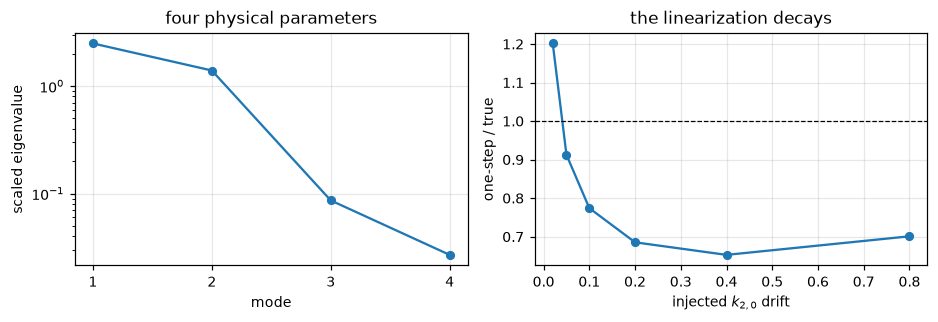

In [30]:
ev4, vec4 = spectrum(d0["H"], PHYS)
print(f"scaled eigenvalues {np.array2string(ev4, precision=4)}")
print(f"scaled condition   {ev4[-1]/ev4[0]:.1f}")
print(f"raw eigenvalues    {np.array2string(np.linalg.eigvalsh(d0['H']), precision=3)}")
print(f"raw condition      {np.linalg.cond(d0['H']):.3g}   (units-dominated, ignore)")
print("\nleast-identified direction:")
print("  " + "  ".join(f"{c:+.3f}*{p}" for c, p in zip(vec4[:, 0], PHYS)))
print("stiffest direction:")
print("  " + "  ".join(f"{c:+.3f}*{p}" for c, p in zip(vec4[:, -1], PHYS)))

fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.0))
ax[0].semilogy(range(1, 5), ev4[::-1], "o-", ms=5)
ax[0].set_xticks(range(1, 5)); ax[0].set_xlabel("mode")
ax[0].set_ylabel("scaled eigenvalue")
ax[0].set_title("four physical parameters")
ax[1].plot(mags, ratios, "o-", ms=5)
ax[1].axhline(1.0, color="k", lw=0.8, ls="--")
ax[1].set_xlabel("injected $k_{2,0}$ drift")
ax[1].set_ylabel("one-step / true")
ax[1].set_title("the linearization decays")
fig.tight_layout()

### Two more, stated rather than measured

**Unobservability.** If a parameter has no effect on any instrument in the
campaign, its score is zero however far it has drifted, and its row of $H$ is
zero too. That shows up as a rank deficiency rather than a small $z$, and the
useful response is the design-of-experiments one from section 8: it is a
question about which instrument to add, not about which estimator to use.

**Parameters at a physical bound.** If a parameter is pinned at a value that
is also a bound it can only move one way, and the covariance has to be
projected onto the active constraint's null space. POUNCE's `covariance`
handles this — it is the subject of
[#922](https://github.com/jkitchin/pounce/issues/922) — but the pin-row idiom
used here deliberately keeps parameters *interior*, which is why the active
set stayed empty throughout.

## What to take away

The diagnostic is five lines, and the expensive part of it is a solve that
was going to run anyway:

```python
_, info, solver = solve_pinned(measurements, theta_hat_0)   # the monitoring solve
s = -np.asarray(info["mult_g"])[pin_rows]                   # score:  free
H = -np.asarray(solver.reduced_hessian(pin_rows)).reshape(p, p)
H = 0.5*(H + H.T)
z = s/np.sqrt(2*np.diag(H))                                 # rank by |z|
```

Read that ranking as a ranking. It named the drifted parameter first in 94% of
600 randomized injections and in its top two 99% of the time, against 84% and
89% for a Wald statistic that costs an extra nonlinear solve, and it is
defined on every campaign rather than the two-thirds where the reduced Hessian
happens to be positive definite. Then refit the one parameter it names, and
check the SSE — a one-parameter refit that reaches the four-parameter fit's
SSE is a much stronger statement about the plant than the four-parameter refit
was.

What the modular workflow is missing is not accuracy. Central differences
across a properly accelerated tear loop got the ranking right in all eighteen
cells tried here, and pretending otherwise would forfeit the argument. What it
is missing is the **multiplier** — the score is a byproduct of solving the
whole flowsheet at once, and a unit-by-unit solve has no such byproduct to
read. That is a structural fact about the two formulations, not a claim about
anyone's software, and it is the same fact that pushes the modular workflow
toward "refit everything and see what moves" — which is the Wald test, at Wald
prices, answering a question with no ranking in it.

Related: [notebook 41](41_delta_planning_vectors.ipynb) reads $\partial
x^\star/\partial p$ off this same factorization to plan setpoint moves;
[notebook 44](44_influence_and_leverage.ipynb) asks the data-direction version
of this notebook's question; [notebook 36](36_parametric_sensitivity.ipynb)
validates one Newton step against a full re-solve.